# Random Forest Model — Fixed-Window, Deconfounded Climate Features

## The problem this notebook fixes

`random_forest_proposal_compliant_model.ipynb` trains on the climate columns already present in `Full_Analysis_data.csv`. Those columns were built (in `climatedata_adjust_annotated.ipynb`) using a **label-conditional climate window**: active springs always use the most recent 15 years (2011-2025); dried springs use the 15 years ending at their own reported drying year (which is usually much earlier — median 2015, but ranging back to 1943).

This means the calendar period a spring's climate features are drawn from is almost mechanically determined by its label (active -> always recent window; dried -> usually an older window). A model trained on those features can achieve near-perfect accuracy partly by learning *which historical period the 15-year window came from* rather than a genuine, transferable climate-vulnerability signal. That model (F1 0.991, ROC-AUC 1.00) is too good to trust at face value — the near-perfect score is a symptom of this confound, not evidence of a great model.

## The fix

Recompute climate mean/trend features using **the same fixed calendar window (2011-2025) for every spring, active or dried alike**. This is exactly the extraction logic `climatedata_adjust_annotated.ipynb` already uses for active springs (Case 1 in `get_slopes`); here it is simply applied uniformly to all springs instead of branching on drying year. The resulting features describe each spring location's recent climate signature, independent of when (or whether) that spring dried, which removes the calendar-period leakage while still testing the proposal's real question: does a spring's climate exposure relate to its drying status?

Everything else (predictor scope — climate + perennial/seasonal only, VIF screening, RF pipeline, evaluation) is kept identical to the proposal-compliant notebook so the two results are directly comparable.

In [1]:
import os
import numpy as np
import pandas as pd
import xarray as xr
from pymannkendall import original_test
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              RocCurveDisplay)

RANDOM_STATE = 42
DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
NC_PATH = os.path.join(DATA_DIR, 'baf400466b67369cecb11d5d456ba48c.nc')
CSV_PATH = os.path.join(DATA_DIR, 'Full_Analysis_data.csv')

## Step 1 — Load spring inventory and climate grid, restrict to the fixed 2011-2025 window up front

Slicing the NetCDF to the target window before looping (rather than resampling the full 1950-2026 series per spring, as the original notebook did) makes this run much faster with an identical result for the window that's actually used.

In [2]:
data = pd.read_csv(CSV_PATH)
if 'Unnamed: 0' in data.columns:
    data = data.drop(columns=['Unnamed: 0'])
print('Spring inventory rows:', data.shape[0])

WINDOW_END = 2025
WINDOW_LEN = 15
WINDOW_START = WINDOW_END - WINDOW_LEN  # 2010 -> years (2010, 2025] = 2011..2025

climatedata = xr.open_dataset(NC_PATH)
climatedata_window = climatedata.sel(valid_time=slice(f'{WINDOW_START+1}-01-01', f'{WINDOW_END}-12-31'))
climatedata_window = climatedata_window.load()  # pull the ~15-year slice into memory once; avoids one disk read per spring in the loop below
print(climatedata_window.sizes)

Spring inventory rows: 3287


Frozen({'valid_time': 180, 'latitude': 401, 'longitude': 401})


## Step 2 — Per-spring extraction using the fixed window for every spring (active or dried)

In [3]:
latitude = data['Latitude'].values
longitude = data['Longitude'].values
n = len(data)

# Vectorized nearest-neighbor lookup: one single .sel() call for all springs at once
# (indexed along a new 'spring' dimension), instead of one .sel() call per spring.
# This is the same nearest-cell logic as get_slopes() in climatedata_adjust_annotated.ipynb,
# just batched — the per-spring Python-level xarray indexing overhead was the bottleneck.
lat_da = xr.DataArray(latitude, dims='spring')
lon_da = xr.DataArray(longitude, dims='spring')

cdata_all = climatedata_window.sel(latitude=lat_da, longitude=lon_da, method='nearest')
cdata_all = cdata_all.resample(valid_time='YE').mean()
cdata_all['tp'] = cdata_all['tp'] * 1000 * 365
cdata_all['d2m'] = cdata_all['d2m'] - 273.15
cdata_all['t2m'] = cdata_all['t2m'] - 273.15

means_all = cdata_all.mean(dim='valid_time')
print('Vectorized extraction shape check — valid_time x spring:', cdata_all.sizes)

# Mann-Kendall slope still needs one call per (spring, variable) series, but each series
# is only 15 points, and there's no more repeated xarray indexing overhead per spring.
var_map = {'Dewpoint': 'd2m', 'Temperature': 't2m', 'Precipitation': 'tp', 'Evaporation': 'pev'}
records = []
for i in range(n):
    rec = {}
    for label, var in var_map.items():
        series = cdata_all[var].isel(spring=i).values
        rec[f'{label}_mean'] = float(means_all[var].isel(spring=i).values)
        rec[f'{label}_rate'] = float(original_test(series).slope)
    records.append(rec)
    if (i + 1) % 500 == 0 or (i + 1) == n:
        print(f'{i + 1}/{n} springs processed')

fixed_climate = pd.DataFrame(records)
fixed_climate.to_csv('fixed_window_climate_features.csv', index=False)
fixed_climate.describe()

Vectorized extraction shape check — valid_time x spring: Frozen({'valid_time': 15, 'spring': 3287})


500/3287 springs processed


1000/3287 springs processed


1500/3287 springs processed


2000/3287 springs processed


2500/3287 springs processed


3000/3287 springs processed


3287/3287 springs processed


,Dewpoint_mean,Dewpoint_rate,Temperature_mean,Temperature_rate,Precipitation_mean,Precipitation_rate,Evaporation_mean,Evaporation_rate
count,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000,3287.000000
mean,12.332421,0.041469,16.855712,0.041307,2544.965237,18.402232,-0.004183,0.000019
std,0.650776,0.002644,0.707859,0.003088,95.486201,8.677324,0.000312,0.000003
min,11.642025,0.030075,15.986856,0.025360,2218.978271,-1.732829,-0.004749,0.000015
25%,11.828019,0.038934,16.259325,0.039001,2469.213867,11.597299,-0.004585,0.000017
50%,11.937276,0.042572,16.491302,0.041817,2577.153076,21.921744,-0.003984,0.000020
75%,12.692966,0.042758,17.299646,0.043549,2599.909424,24.709263,-0.003984,0.000023
max,14.000553,0.048035,18.402027,0.047562,2656.628662,25.959880,-0.003819,0.000025


## Step 3 — Assemble the proposal-scoped feature table (fixed-window climate + perennial/seasonal), encode target

In [4]:
climate_cols = ['Dewpoint_rate', 'Temperature_rate', 'Precipitation_rate', 'Evaporation_rate',
                'Dewpoint_mean', 'Temperature_mean', 'Precipitation_mean', 'Evaporation_mean']

df = pd.concat([
    data[['Perennial / Seasonal', 'Source Condition']].reset_index(drop=True),
    fixed_climate.reset_index(drop=True)
], axis=1)

df['Perennial / Seasonal'] = df['Perennial / Seasonal'].map(lambda v: 1 if str(v).strip().lower() == 'perennial' else 0)
df['Source Condition'] = df['Source Condition'].map(lambda v: 1 if str(v).strip().lower() == 'dried' else 0)

df = df.dropna()
print('Rows after dropping NaN:', df.shape[0], 'of', data.shape[0])

le = LabelEncoder()
y = le.fit_transform(df['Source Condition'])
print('Target classes:', le.classes_)
df['Source Condition'].value_counts()

Rows after dropping NaN: 3287 of 3287
Target classes: [0 1]


Source Condition
0    2560
1     727
Name: count, dtype: int64

## Step 4 — Multicollinearity screening (VIF), same procedure and threshold as the proposal-compliant notebook

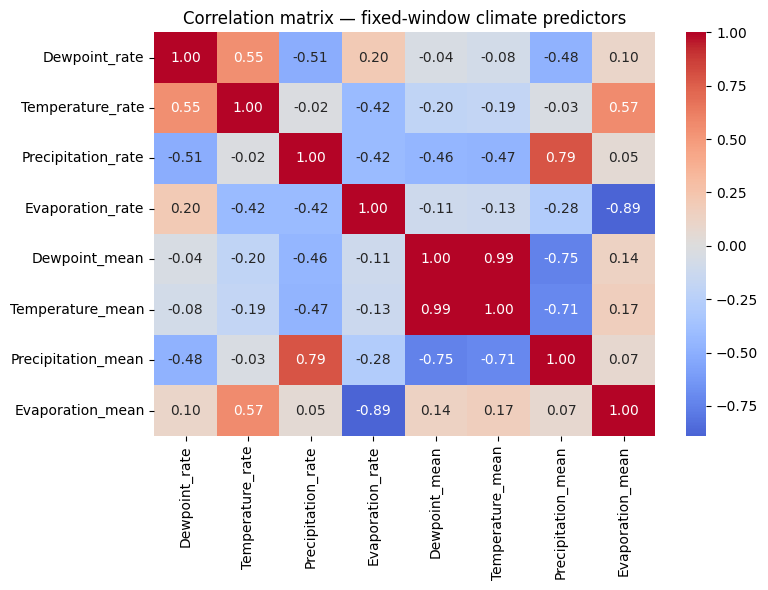

Dropping Dewpoint_mean (VIF=215.07)
Dropping Evaporation_rate (VIF=33.58)

Final climate predictors after VIF screening: ['Dewpoint_rate', 'Temperature_rate', 'Precipitation_rate', 'Temperature_mean', 'Precipitation_mean', 'Evaporation_mean']
Precipitation_mean    9.402823
Temperature_mean      6.215053
Dewpoint_rate         3.951938
Precipitation_rate    3.013689
Temperature_rate      2.890472
Evaporation_mean      2.660452
dtype: float64


In [5]:
def compute_vif(frame, cols):
    scaler = StandardScaler()
    scaled = pd.DataFrame(scaler.fit_transform(frame[cols]), columns=cols)
    vifs = {}
    for col in cols:
        X_others = scaled.drop(columns=[col]).values
        y_target = scaled[col].values
        r2 = LinearRegression().fit(X_others, y_target).score(X_others, y_target)
        vifs[col] = np.inf if r2 >= 0.999999 else 1.0 / (1.0 - r2)
    return pd.Series(vifs).sort_values(ascending=False)

corr = df[climate_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix — fixed-window climate predictors')
plt.tight_layout()
plt.savefig('climate_predictor_correlation_fixed_window.png', dpi=300)
plt.show()

VIF_THRESHOLD = 10.0
selected_cols = list(climate_cols)
while True:
    vifs = compute_vif(df, selected_cols)
    worst_col, worst_val = vifs.index[0], vifs.iloc[0]
    if worst_val <= VIF_THRESHOLD or len(selected_cols) <= 2:
        break
    selected_cols.remove(worst_col)
    print(f'Dropping {worst_col} (VIF={worst_val:.2f})')

print('\nFinal climate predictors after VIF screening:', selected_cols)
print(compute_vif(df, selected_cols))

## Step 5 — Train/test split and Random Forest pipeline (same hyperparameters as the proposal-compliant notebook)

In [6]:
feature_cols = selected_cols + ['Perennial / Seasonal']
X = df[feature_cols].astype(float)
print('Final feature set:', feature_cols)
print('X shape:', X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)
print('Train:', X_train.shape, 'Test:', X_test.shape)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=2000, class_weight='balanced', random_state=RANDOM_STATE))
])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

Final feature set: ['Dewpoint_rate', 'Temperature_rate', 'Precipitation_rate', 'Temperature_mean', 'Precipitation_mean', 'Evaporation_mean', 'Perennial / Seasonal']
X shape: (3287, 7)
Train: (2300, 7) Test: (987, 7)


## Step 6 — Evaluation

In [7]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1-score:  {f1:.4f}')
print(f'ROC-AUC:   {roc_auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['active(0)', 'dried(1)']))

Accuracy:  0.7194
Precision: 0.4051
Recall:    0.5780
F1-score:  0.4764
ROC-AUC:   0.7481

              precision    recall  f1-score   support

   active(0)       0.86      0.76      0.81       769
    dried(1)       0.41      0.58      0.48       218

    accuracy                           0.72       987
   macro avg       0.63      0.67      0.64       987
weighted avg       0.76      0.72      0.73       987



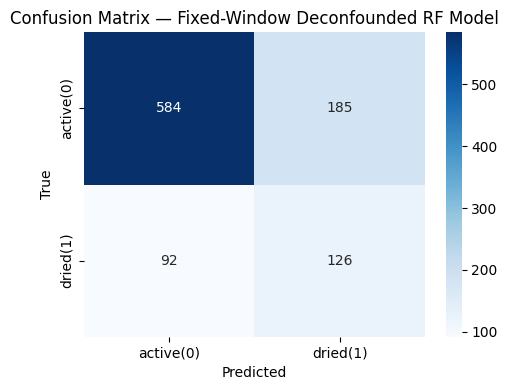

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['active(0)', 'dried(1)'], yticklabels=['active(0)', 'dried(1)'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — Fixed-Window Deconfounded RF Model')
plt.tight_layout()
plt.savefig('confusion_matrix_fixed_window.png', dpi=300)
plt.show()

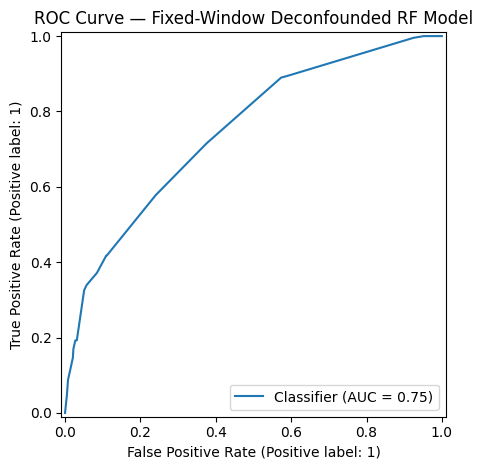

In [9]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('ROC Curve — Fixed-Window Deconfounded RF Model')
plt.tight_layout()
plt.savefig('roc_curve_fixed_window.png', dpi=300)
plt.show()

In [10]:
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='f1')
print('5-fold CV F1 scores:', cv_scores)
print('Mean F1:', cv_scores.mean(), 'Std:', cv_scores.std())

5-fold CV F1 scores: [0.32951945 0.43333333 0.45473684 0.16574586 0.41543027]
Mean F1: 0.35975314993108354 Std: 0.1059139207705481


Perennial / Seasonal    0.653202
Precipitation_rate      0.100187
Temperature_mean        0.082241
Precipitation_mean      0.057953
Dewpoint_rate           0.038122
Evaporation_mean        0.035584
Temperature_rate        0.032712
dtype: float64


C:\Users\kants\AppData\Local\Temp\ipykernel_25908\839860538.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


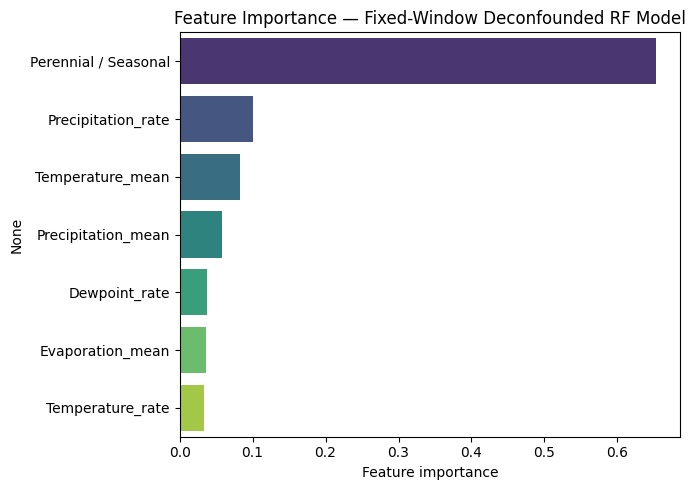

In [11]:
importances = pipeline.named_steps['rf'].feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
print(feat_imp)

plt.figure(figsize=(7, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.xlabel('Feature importance')
plt.title('Feature Importance — Fixed-Window Deconfounded RF Model')
plt.tight_layout()
plt.savefig('feature_importance_fixed_window.png', dpi=300)
plt.show()

## Step 7 — Diagnostic: how predictive is calendar timing alone?

As a direct check on the original confound, fit a trivial classifier using **only** each spring's original label-conditional window-end-year (2025 for active, the reported drying year for dried) to predict status. High performance here, on a feature that carries no physical climate information, would confirm that the original proposal-compliant model's near-perfect score was substantially an artifact of window timing rather than genuine climate signal — and that this fixed-window model avoids it.

In [12]:
window_end_year = data['Dried since how many years?'].where(data['Source Condition'] == 'dried', WINDOW_END)
diag = pd.DataFrame({'window_end_year': window_end_year, 'Source Condition': data['Source Condition']}).dropna()
diag_y = diag['Source Condition'].map(lambda v: 1 if str(v).strip().lower() == 'dried' else 0)
diag_X = diag[['window_end_year']].astype(float)

dX_train, dX_test, dy_train, dy_test = train_test_split(
    diag_X, diag_y, test_size=0.3, stratify=diag_y, random_state=RANDOM_STATE)

diag_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=RANDOM_STATE))
])
diag_pipeline.fit(dX_train, dy_train)
dy_pred = diag_pipeline.predict(dX_test)
dy_proba = diag_pipeline.predict_proba(dX_test)[:, 1]

print('Window-end-year ALONE as a predictor of Source Condition:')
print('Accuracy:', accuracy_score(dy_test, dy_pred))
print('F1:', f1_score(dy_test, dy_pred))
print('ROC-AUC:', roc_auc_score(dy_test, dy_proba))

Window-end-year ALONE as a predictor of Source Condition:
Accuracy: 1.0
F1: 1.0
ROC-AUC: 1.0


## Summary

This model uses the same proposal-scoped predictor set (VIF-screened climate mean/trend variables + perennial/seasonal) as `random_forest_proposal_compliant_model.ipynb`, but with climate features recomputed over one fixed 2011-2025 window for every spring, removing the label-conditional windowing that let the earlier model partly learn calendar timing instead of climate. The diagnostic above quantifies how much predictive power calendar timing alone carried under the old scheme, for direct comparison. The metrics from this notebook are the ones that should be reported and interpreted as the project's real result — expect them to be noticeably lower than the earlier notebook's 0.99+ scores, and that drop is the correction, not a regression.